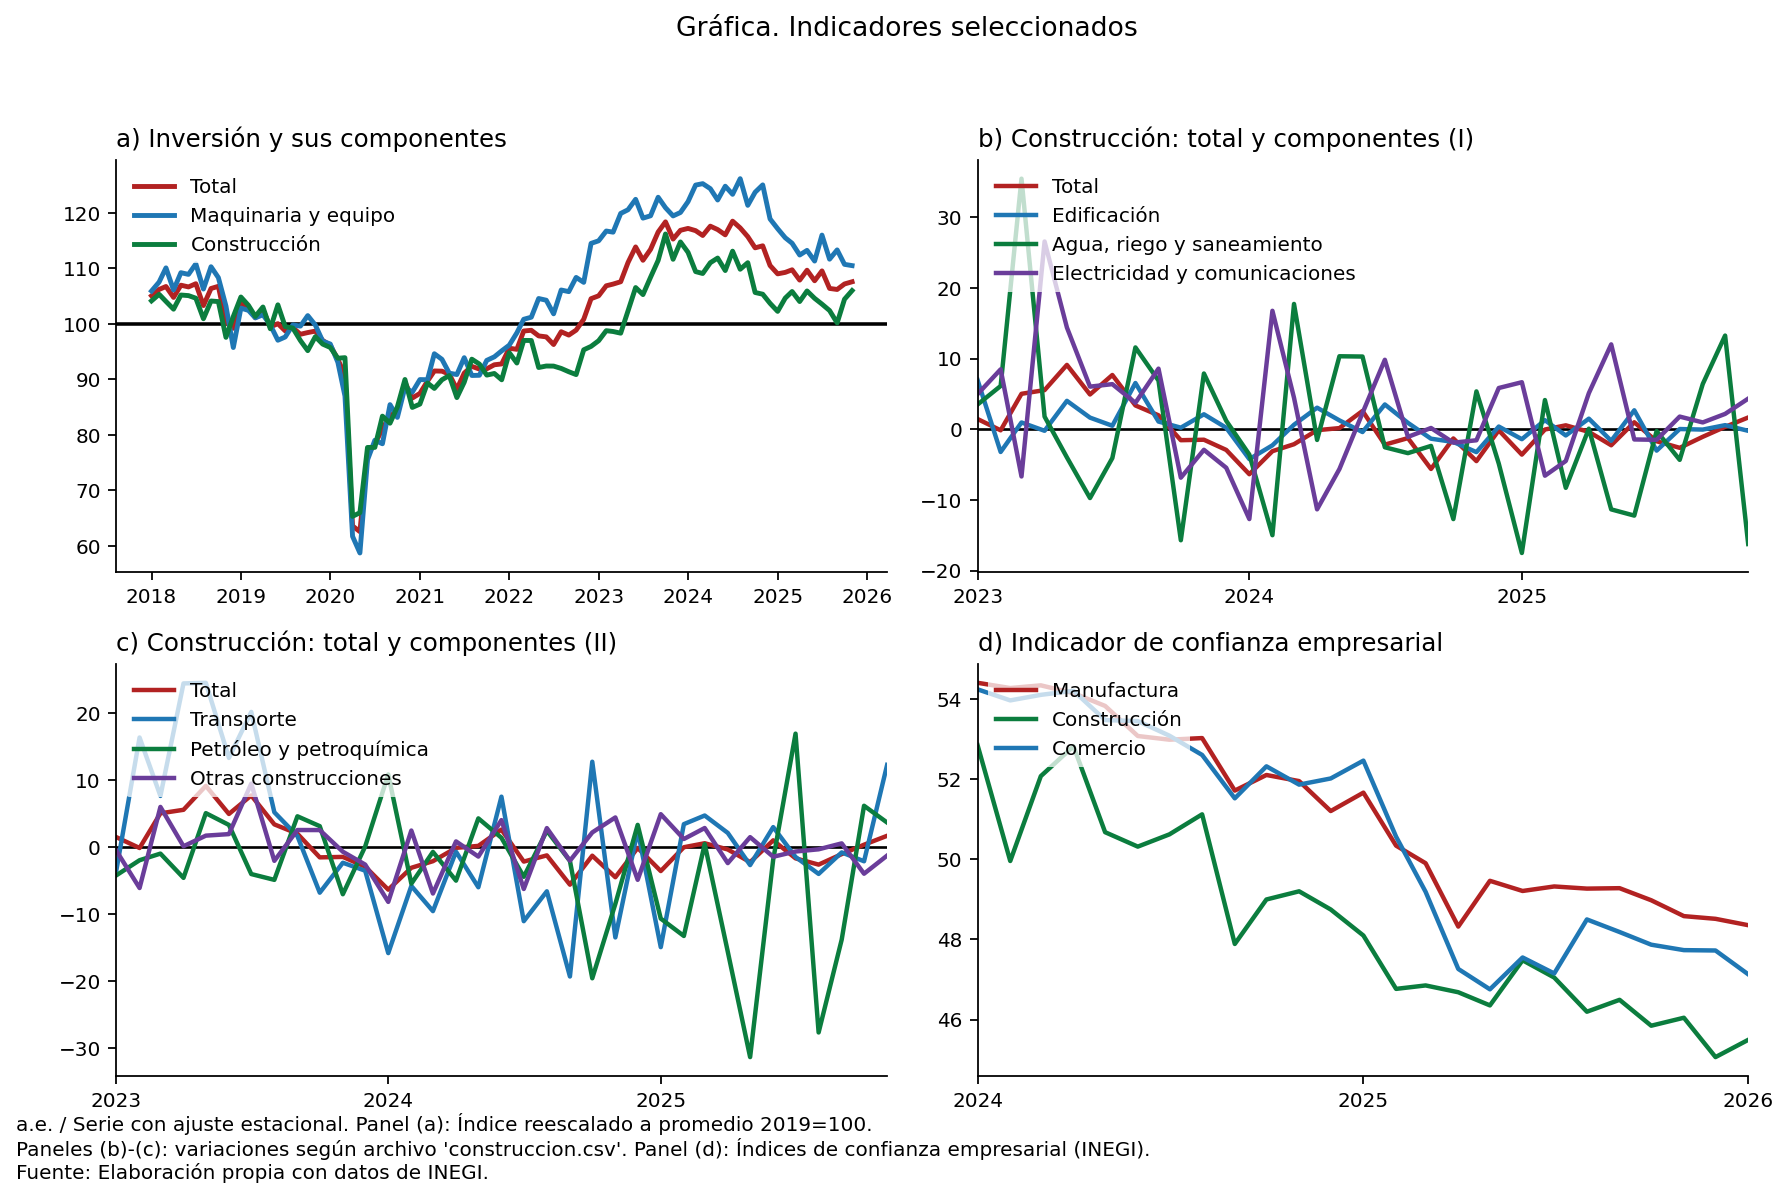

In [27]:
# ============================================================
# FIGURA 2x2 (a)-(d) — CÓDIGO COMPLETO CORREGIDO
# - (a) IFB (Excel con merges): TOTAL, Maquinaria y equipo, Construcción (rebased a 2019=100)
# - (b) construccion.csv: Total + 3 componentes (grupo 1)
# - (c) construccion.csv: Total + 3 componentes (grupo 2)
# - (d) confianza_empresarial.csv: Manufactura, Construcción, Comercio (TOTAL)  <-- tu archivo NO trae mayor/menor
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import openpyxl
from openpyxl.utils import range_boundaries

# =========================
# PATHS (ajusta si cambian)
# =========================
PATH_IFB   = "raw/ifb_indice.xlsx"
PATH_CONST = "raw/construccion.csv"
PATH_CONF  = "raw/confianza_empresarial.csv"

START = pd.Timestamp("2018-01-01")
BASE_YEAR = 2019

# =========================
# ESTILO (Banxico-like)
# =========================
plt.rcParams.update({
    "figure.dpi": 160,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

COL_TOTAL  = "#b22222"   # vino
COL_AZUL   = "#1f77b4"
COL_VERDE  = "#0b7d3e"
COL_MORADO = "#6a3d9a"

def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

def legend_box(ax, loc="upper left"):
    leg = ax.legend(loc=loc, frameon=True)
    leg.get_frame().set_alpha(0.75)
    leg.get_frame().set_linewidth(0.0)
    return leg

def add_base100(ax):
    ax.axhline(100, lw=1.6, color="black", zorder=1)

def add_zero(ax):
    ax.axhline(0, lw=1.2, color="black", zorder=1)

# =========================
# 1) EXCEL: RELLENAR MERGES
# =========================
def sheet_to_matrix_fill_merged(path: str, sheet_name: str) -> pd.DataFrame:
    wb = openpyxl.load_workbook(path, data_only=True)
    ws = wb[sheet_name]

    merged_map = {}
    for r in ws.merged_cells.ranges:
        min_col, min_row, max_col, max_row = range_boundaries(str(r))
        v = ws.cell(min_row, min_col).value
        for rr in range(min_row, max_row + 1):
            for cc in range(min_col, max_col + 1):
                merged_map[(rr, cc)] = v

    data = []
    for rr in range(1, ws.max_row + 1):
        row = []
        for cc in range(1, ws.max_column + 1):
            v = ws.cell(rr, cc).value
            if v is None and (rr, cc) in merged_map:
                v = merged_map[(rr, cc)]
            row.append(v)
        data.append(row)

    return pd.DataFrame(data)

# ============================================
# 2) IFB: LECTOR MATRIZ INEGI (AÑOS + MESES)
# ============================================
MONTH_MAP = {"ENE":1,"FEB":2,"MAR":3,"ABR":4,"MAY":5,"JUN":6,"JUL":7,"AGO":8,"SEP":9,"OCT":10,"NOV":11,"DIC":12}

def read_inegi_wide_matrix_excel(
    path: str,
    sheet_name: str,
    header_year_row: int = 5,   # 1-based
    header_month_row: int = 6,  # 1-based
    series_start_row: int = 7,  # 1-based
) -> pd.DataFrame:
    mat = sheet_to_matrix_fill_merged(path, sheet_name)

    yr = mat.iloc[header_year_row - 1]
    mo = mat.iloc[header_month_row - 1]

    # localizar "ENE"
    data_start_j = None
    for j, v in enumerate(mo):
        if isinstance(v, str) and v.strip().upper() == "ENE":
            data_start_j = j
            break
    if data_start_j is None:
        raise ValueError("No encontré 'ENE' en fila de meses. Revisa header_month_row.")

    cols_j, dates = [], []
    for j in range(data_start_j, mat.shape[1]):
        y = yr.iloc[j]
        m = mo.iloc[j]
        if y is None or m is None:
            continue

        try:
            y_int = int(str(y).strip())
        except:
            continue

        m_key = str(m).strip().upper()[:3]
        if m_key not in MONTH_MAP:
            continue

        cols_j.append(j)
        dates.append(pd.Timestamp(y_int, MONTH_MAP[m_key], 1))

    records = []
    for i in range(series_start_row - 1, mat.shape[0]):
        c1 = mat.iat[i, 0]
        c2 = mat.iat[i, 1]

        if isinstance(c1, str) and c1.strip().lower().startswith("nota"):
            break
        if c1 is None and c2 is None:
            continue

        name = c1 if c1 is not None else c2
        if not isinstance(name, str):
            continue
        name = re.sub(r"\s+", " ", name.replace("\n", " ")).strip()

        vals = pd.to_numeric(mat.iloc[i, cols_j], errors="coerce").values
        for d, v in zip(dates, vals):
            if pd.notna(v):
                records.append((d, name, float(v)))

    return pd.DataFrame(records, columns=["date","serie","value"]).sort_values(["serie","date"])

def rebase_to_year_avg(s: pd.Series, base_year: int = 2019) -> pd.Series:
    base = s[s.index.year == base_year].mean()
    return (s / base) * 100

def prep_ifb_series(ifb_long: pd.DataFrame, start="2018-01-01", base_year=2019) -> pd.DataFrame:
    df = ifb_long.copy()
    df = df[df["date"] >= pd.Timestamp(start)]
    wide = df.pivot(index="date", columns="serie", values="value").sort_index()
    wide.columns = [re.sub(r"\s+", " ", str(c).replace("\n", " ")).strip() for c in wide.columns]
    wide_rb = wide.apply(lambda col: rebase_to_year_avg(col, base_year=base_year), axis=0)
    return wide_rb

# ============================================
# 3) construccion.csv: filas-año + meses abajo
# ============================================
def read_monthly_csv_with_year_rows(path: str, periodo_col: str = "Periodo") -> pd.DataFrame:
    df_raw = pd.read_csv(path)
    df_raw.columns = [re.sub(r"\s+", " ", str(c).strip()) for c in df_raw.columns]

    month_map = {
        "Enero":1,"Febrero":2,"Marzo":3,"Abril":4,"Mayo":5,"Junio":6,
        "Julio":7,"Agosto":8,"Septiembre":9,"Octubre":10,"Noviembre":11,"Diciembre":12
    }

    records, year = [], None
    for _, row in df_raw.iterrows():
        per = str(row[periodo_col]).strip()

        if re.fullmatch(r"\d{4}", per):
            year = int(per)
            continue
        if year is None:
            continue

        per = re.sub(r"\s+P$", "", per)
        per = re.sub(r"\s+", " ", per)

        m = month_map.get(per, None)
        if m is None:
            continue

        rec = {"date": pd.Timestamp(year, m, 1)}
        for c in df_raw.columns:
            if c == periodo_col:
                continue
            rec[c] = pd.to_numeric(row[c], errors="coerce")
        records.append(rec)

    df = pd.DataFrame(records).sort_values("date").reset_index(drop=True)
    df.columns = [re.sub(r"\s+", " ", str(c).strip()) for c in df.columns]
    return df

def resolve_col(df: pd.DataFrame, target: str) -> str:
    """
    Encuentra la columna cuyo nombre contenga target (ignorando '...' y minúsculas).
    Útil cuando Excel muestra '...' pero el CSV trae el nombre completo.
    """
    t = target.lower().replace("...", "").strip()
    for c in df.columns:
        if c == "date":
            continue
        cn = str(c).lower().replace("...", "").strip()
        if t and t in cn:
            return c
    if target in df.columns:
        return target
    raise KeyError(f"No pude resolver columna '{target}'. Disponibles: {list(df.columns)}")

# ============================================
# 4) confianza_empresarial.csv (TU ARCHIVO = 3 SECTORES)
# ============================================
def read_confianza_empresarial_3sectores(path: str) -> pd.DataFrame:
    """
    Tu archivo trae SOLO:
      Sector manufacturero (índice, dif_m, dif_a)
      Sector construcción (índice, dif_m, dif_a)
      Sector comercio (índice, dif_m, dif_a)
    => 9 números por mes.
    """
    month_map = {
        "Enero":1,"Febrero":2,"Marzo":3,"Abril":4,"Mayo":5,"Junio":6,
        "Julio":7,"Agosto":8,"Septiembre":9,"Octubre":10,"Noviembre":11,"Diciembre":12
    }

    rows, year = [], None
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for ln in f:
            ln = ln.strip()
            if not ln:
                continue
            ln = ln.lstrip("\ufeff")

            if re.fullmatch(r"\d{4}", ln):
                year = int(ln)
                continue

            low = ln.lower()
            if low.startswith("periodo") or low.startswith("índice") or low.startswith("indice") or low.startswith("mensual"):
                continue

            if year is None:
                continue

            parts = [p.strip() for p in ln.split(",")]
            if len(parts) < 10:
                continue

            mstr = re.sub(r"\s+P$", "", parts[0]).strip()
            if mstr not in month_map:
                continue

            try:
                nums = list(map(float, parts[1:10]))  # 9 números
            except:
                continue

            rec = {
                "date": pd.Timestamp(year, month_map[mstr], 1),
                "manuf_indice": nums[0],
                "cons_indice":  nums[3],
                "com_indice":   nums[6],
            }
            rows.append(rec)

    df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    return df

# =========================
# 5) CARGAR DATOS
# =========================
# IFB
ifb_long = read_inegi_wide_matrix_excel(PATH_IFB, sheet_name="FBKF_indice")
ifb = prep_ifb_series(ifb_long, start=str(START.date()), base_year=BASE_YEAR)

# Construcción (variaciones)
constr = read_monthly_csv_with_year_rows(PATH_CONST, periodo_col="Periodo")
constr = constr[constr["date"] >= START].copy()

# Confianza (3 sectores)
conf = read_confianza_empresarial_3sectores(PATH_CONF)
conf = conf[conf["date"] >= START].copy()

# =========================
# 6) DEFINIR GRUPOS (b) y (c)
# =========================
# Ajusta targets si cambian tus nombres (esto ya es robusto a nombres largos)
g1_targets = ["Total", "Edificación", "Agua, riego", "Electricidad"]
g2_targets = ["Total", "Transporte", "Petróleo", "Otras construcciones"]

g1_cols = [resolve_col(constr, t) for t in g1_targets]
g2_cols = [resolve_col(constr, t) for t in g2_targets]

# =========================
# 7) FIGURA 2x2
# =========================
fig, axes = plt.subplots(2, 2, figsize=(11.6, 7.6))
(ax_a, ax_b), (ax_c, ax_d) = axes

# -------- (a) IFB --------
# Si llegara a cambiar el nombre de TOTAL, aquí lo forzamos:
# imprime columnas si algo falla:
# print(ifb.columns)

a_df = ifb[["TOTAL", "Maquinaria y equipo", "Construcción"]].copy()

ax_a.plot(a_df.index, a_df["TOTAL"],               lw=2.2, color=COL_TOTAL, label="Total")
ax_a.plot(a_df.index, a_df["Maquinaria y equipo"], lw=2.2, color=COL_AZUL,  label="Maquinaria y equipo")
ax_a.plot(a_df.index, a_df["Construcción"],        lw=2.2, color=COL_VERDE, label="Construcción")

add_base100(ax_a)
style_axis(ax_a)
ax_a.set_title("a) Inversión y sus componentes", loc="left", pad=6)
legend_box(ax_a, loc="upper left")

# -------- (b) Construcción (I) --------
colors_b = [COL_TOTAL, COL_AZUL, COL_VERDE, COL_MORADO]
labels_b = ["Total", "Edificación", "Agua, riego y saneamiento", "Electricidad y comunicaciones"]

for c, col, lab in zip(colors_b, g1_cols, labels_b):
    ax_b.plot(constr["date"], constr[col], lw=2.0, color=c, label=lab)

add_zero(ax_b)
style_axis(ax_b)
ax_b.set_title("b) Construcción: total y componentes (I)", loc="left", pad=6)
legend_box(ax_b, loc="upper left")
# recorte para que (b) se vea como en tu output (2023+)
ax_b.set_xlim(pd.Timestamp("2023-01-01"), constr["date"].max())

# -------- (c) Construcción (II) --------
colors_c = [COL_TOTAL, COL_AZUL, COL_VERDE, COL_MORADO]
labels_c = ["Total", "Transporte", "Petróleo y petroquímica", "Otras construcciones"]

for c, col, lab in zip(colors_c, g2_cols, labels_c):
    ax_c.plot(constr["date"], constr[col], lw=2.0, color=c, label=lab)

add_zero(ax_c)
style_axis(ax_c)
ax_c.set_title("c) Construcción: total y componentes (II)", loc="left", pad=6)
legend_box(ax_c, loc="upper left")
ax_c.set_xlim(pd.Timestamp("2023-01-01"), constr["date"].max())

# -------- (d) Confianza empresarial (3 sectores) --------
ax_d.plot(conf["date"], conf["manuf_indice"], lw=2.0, color=COL_TOTAL, label="Manufactura")
ax_d.plot(conf["date"], conf["cons_indice"],  lw=2.0, color=COL_VERDE, label="Construcción")
ax_d.plot(conf["date"], conf["com_indice"],   lw=2.0, color=COL_AZUL,  label="Comercio")

style_axis(ax_d)
ax_d.set_title("d) Indicador de confianza empresarial", loc="left", pad=6)
legend_box(ax_d, loc="upper left")
ax_d.set_xlim(conf["date"].min(), conf["date"].max())

# -------- Título + nota al pie --------
fig.suptitle("Gráfica. Indicadores seleccionados", y=0.98, fontsize=12)

fig.text(
    0.02, 0.02,
    "a.e. / Serie con ajuste estacional. Panel (a): Índice reescalado a promedio 2019=100.\n"
    "Paneles (b)-(c): variaciones según archivo 'construccion.csv'. Panel (d): Índices de confianza empresarial (INEGI).\n"
    "Fuente: Elaboración propia con datos de INEGI.",
    ha="left", va="bottom", fontsize=9
)

plt.tight_layout(rect=[0.03, 0.06, 0.98, 0.95])
plt.show()


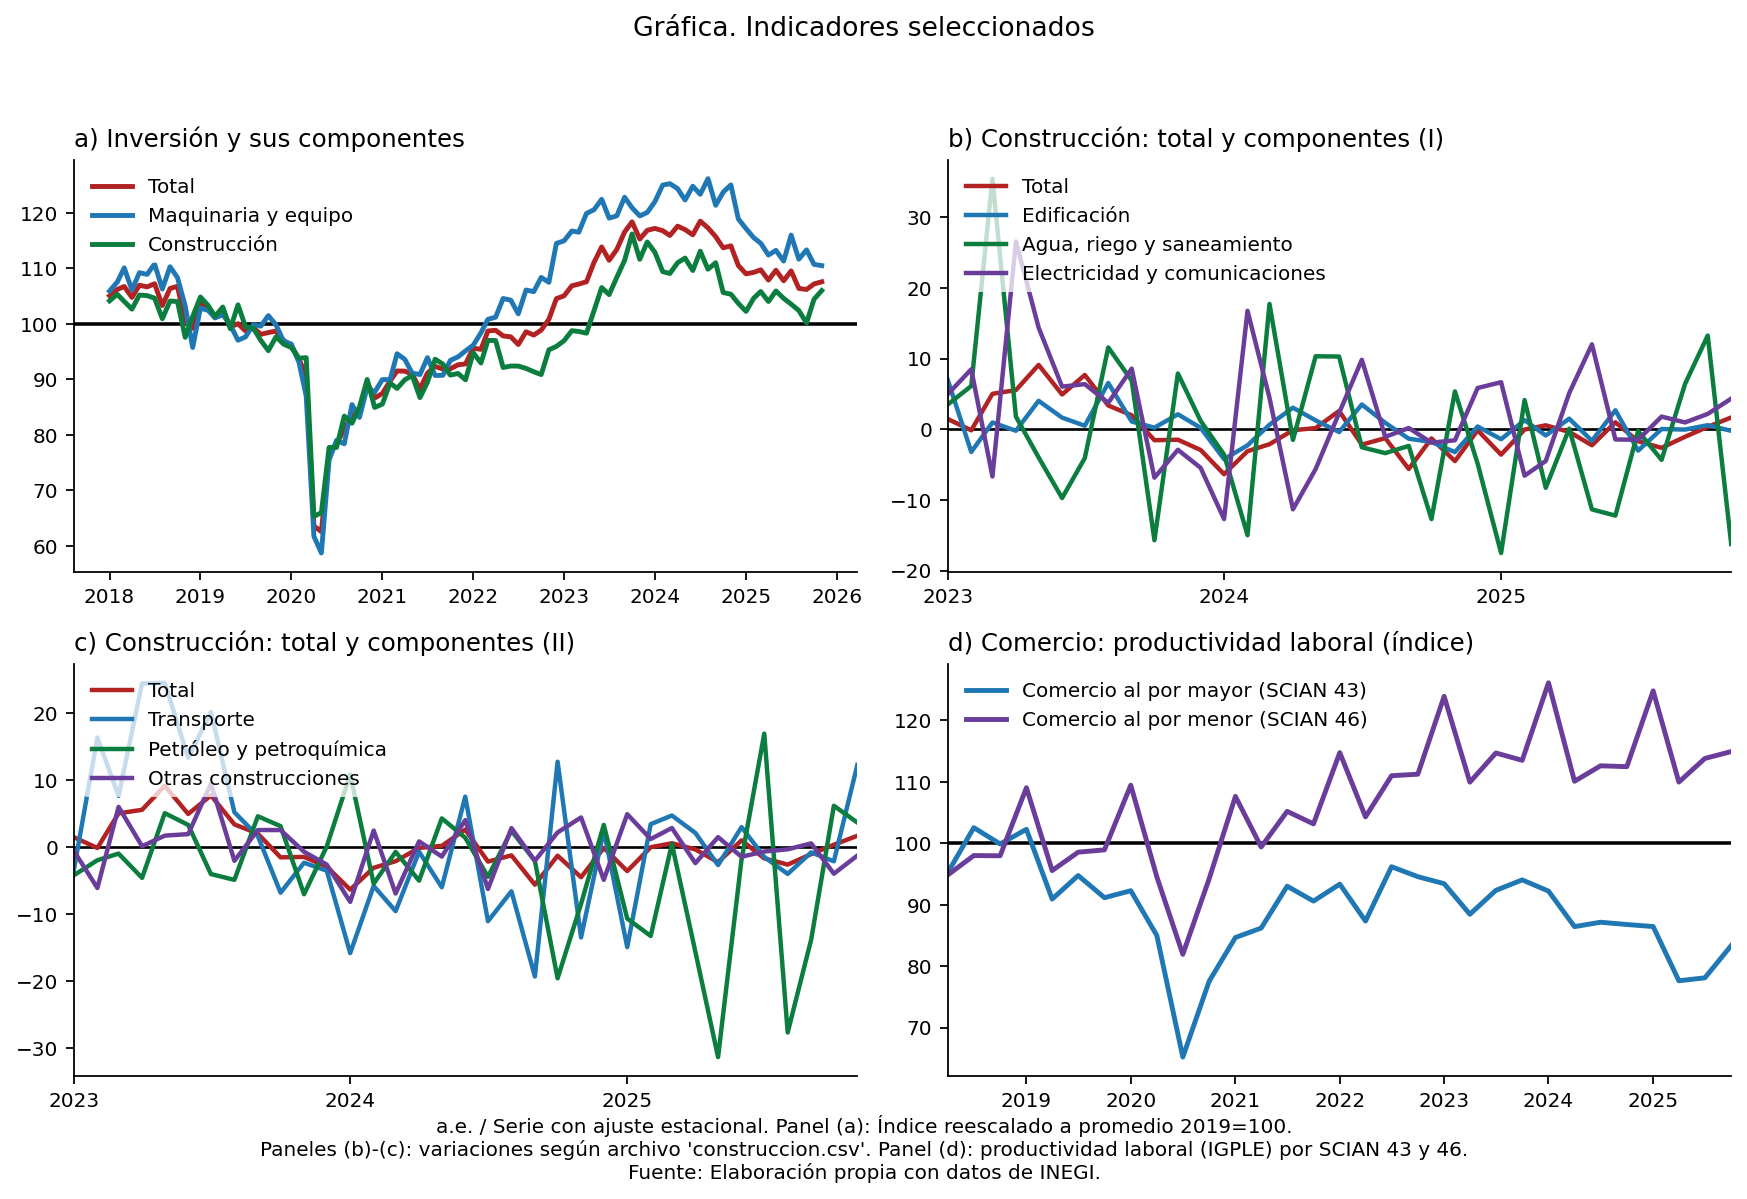

In [28]:
# ============================================================
# FIGURA 2x2 (a)-(d) — CÓDIGO COMPLETO CORREGIDO
# (a) IFB (Excel con merges): TOTAL, Maquinaria y equipo, Construcción (rebased 2019=100)
# (b) construccion.csv: Total + 3 componentes (grupo 1)
# (c) construccion.csv: Total + 3 componentes (grupo 2)
# (d) prod_empresas.xlsx: Comercio al por mayor (43) y al por menor (46) (trimestral)
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import openpyxl
from openpyxl.utils import range_boundaries

# =========================
# PATHS (montados aquí)
# =========================
PATH_IFB   = "raw/ifb_indice.xlsx"
PATH_CONST = "raw/construccion.csv"
PATH_PROD  = "raw/prod_empresas.xlsx"

START = pd.Timestamp("2018-01-01")
BASE_YEAR = 2019

# =========================
# ESTILO
# =========================
plt.rcParams.update({
    "figure.dpi": 160,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

COL_TOTAL  = "#b22222"   # vino
COL_AZUL   = "#1f77b4"
COL_VERDE  = "#0b7d3e"
COL_MORADO = "#6a3d9a"

def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

def legend_box(ax, loc="upper left"):
    leg = ax.legend(loc=loc, frameon=True)
    leg.get_frame().set_alpha(0.75)
    leg.get_frame().set_linewidth(0.0)
    return leg

def add_base100(ax):
    ax.axhline(100, lw=1.6, color="black", zorder=1)

def add_zero(ax):
    ax.axhline(0, lw=1.2, color="black", zorder=1)

# =========================
# 1) EXCEL: RELLENAR MERGES
# =========================
def sheet_to_matrix_fill_merged(path: str, sheet_name: str) -> pd.DataFrame:
    wb = openpyxl.load_workbook(path, data_only=True)
    ws = wb[sheet_name]

    merged_map = {}
    for r in ws.merged_cells.ranges:
        min_col, min_row, max_col, max_row = range_boundaries(str(r))
        v = ws.cell(min_row, min_col).value
        for rr in range(min_row, max_row + 1):
            for cc in range(min_col, max_col + 1):
                merged_map[(rr, cc)] = v

    data = []
    for rr in range(1, ws.max_row + 1):
        row = []
        for cc in range(1, ws.max_column + 1):
            v = ws.cell(rr, cc).value
            if v is None and (rr, cc) in merged_map:
                v = merged_map[(rr, cc)]
            row.append(v)
        data.append(row)

    return pd.DataFrame(data)

# ============================================
# 2) IFB: MATRIZ INEGI (AÑOS + MESES)
# ============================================
MONTH_MAP = {"ENE":1,"FEB":2,"MAR":3,"ABR":4,"MAY":5,"JUN":6,"JUL":7,"AGO":8,"SEP":9,"OCT":10,"NOV":11,"DIC":12}

def read_inegi_wide_matrix_excel(
    path: str,
    sheet_name: str,
    header_year_row: int = 5,   # 1-based
    header_month_row: int = 6,  # 1-based
    series_start_row: int = 7,  # 1-based
) -> pd.DataFrame:
    mat = sheet_to_matrix_fill_merged(path, sheet_name)

    yr = mat.iloc[header_year_row - 1]
    mo = mat.iloc[header_month_row - 1]

    # localizar "ENE"
    data_start_j = None
    for j, v in enumerate(mo):
        if isinstance(v, str) and v.strip().upper() == "ENE":
            data_start_j = j
            break
    if data_start_j is None:
        raise ValueError("No encontré 'ENE' en fila de meses. Revisa header_month_row.")

    cols_j, dates = [], []
    for j in range(data_start_j, mat.shape[1]):
        y = yr.iloc[j]
        m = mo.iloc[j]
        if y is None or m is None:
            continue

        try:
            y_int = int(str(y).strip())
        except:
            continue

        m_key = str(m).strip().upper()[:3]
        if m_key not in MONTH_MAP:
            continue

        cols_j.append(j)
        dates.append(pd.Timestamp(y_int, MONTH_MAP[m_key], 1))

    records = []
    for i in range(series_start_row - 1, mat.shape[0]):
        c1 = mat.iat[i, 0]
        c2 = mat.iat[i, 1]

        if isinstance(c1, str) and c1.strip().lower().startswith("nota"):
            break
        if c1 is None and c2 is None:
            continue

        name = c1 if c1 is not None else c2
        if not isinstance(name, str):
            continue
        name = re.sub(r"\s+", " ", name.replace("\n", " ")).strip()

        vals = pd.to_numeric(mat.iloc[i, cols_j], errors="coerce").values
        for d, v in zip(dates, vals):
            if pd.notna(v):
                records.append((d, name, float(v)))

    return pd.DataFrame(records, columns=["date","serie","value"]).sort_values(["serie","date"])

def rebase_to_year_avg(s: pd.Series, base_year: int = 2019) -> pd.Series:
    base = s[s.index.year == base_year].mean()
    return (s / base) * 100

def prep_ifb_series(ifb_long: pd.DataFrame, start="2018-01-01", base_year=2019) -> pd.DataFrame:
    df = ifb_long.copy()
    df = df[df["date"] >= pd.Timestamp(start)]
    wide = df.pivot(index="date", columns="serie", values="value").sort_index()
    wide.columns = [re.sub(r"\s+", " ", str(c).replace("\n", " ")).strip() for c in wide.columns]
    wide_rb = wide.apply(lambda col: rebase_to_year_avg(col, base_year=base_year), axis=0)
    return wide_rb

# ============================================
# 3) construccion.csv: filas-año + meses abajo
# ============================================
def read_monthly_csv_with_year_rows(path: str, periodo_col: str = "Periodo") -> pd.DataFrame:
    df_raw = pd.read_csv(path)
    df_raw.columns = [re.sub(r"\s+", " ", str(c).strip()) for c in df_raw.columns]

    month_map = {
        "Enero":1,"Febrero":2,"Marzo":3,"Abril":4,"Mayo":5,"Junio":6,
        "Julio":7,"Agosto":8,"Septiembre":9,"Octubre":10,"Noviembre":11,"Diciembre":12
    }

    records, year = [], None
    for _, row in df_raw.iterrows():
        per = str(row[periodo_col]).strip()

        if re.fullmatch(r"\d{4}", per):
            year = int(per)
            continue
        if year is None:
            continue

        per = re.sub(r"\s+P$", "", per)
        per = re.sub(r"\s+", " ", per)

        m = month_map.get(per, None)
        if m is None:
            continue

        rec = {"date": pd.Timestamp(year, m, 1)}
        for c in df_raw.columns:
            if c == periodo_col:
                continue
            rec[c] = pd.to_numeric(row[c], errors="coerce")
        records.append(rec)

    df = pd.DataFrame(records).sort_values("date").reset_index(drop=True)
    df.columns = [re.sub(r"\s+", " ", str(c).strip()) for c in df.columns]
    return df

def resolve_col(df: pd.DataFrame, target: str) -> str:
    t = target.lower().replace("...", "").strip()
    for c in df.columns:
        if c == "date":
            continue
        cn = str(c).lower().replace("...", "").strip()
        if t and t in cn:
            return c
    if target in df.columns:
        return target
    raise KeyError(f"No pude resolver columna '{target}'. Disponibles: {list(df.columns)}")

# ============================================
# 4) prod_empresas.xlsx: CABECERA (AÑO, TRIMESTRE) + SECTOR SCIAN
# ============================================
def read_prod_empresas_trimestral(path: str, sheet_name: str = "Tabulado") -> pd.DataFrame:
    """
    Lee la hoja Tabulado de prod_empresas.xlsx (con merges) y regresa formato largo:
      date (timestamp trimestral), sector_scian (str), value (float)

    Estructura detectada (como tu screenshot):
      - Fila de años (ej. '2018' repetido por columnas)
      - Fila de trimestres ('1T','2T','3T','4T')
      - Columna 'Sector SCIAN' con filas:
          '43 Comercio al por mayor', '46 Comercio al por menor', etc.
    """
    mat = sheet_to_matrix_fill_merged(path, sheet_name)

    # localizar la fila donde aparece "Sector SCIAN"
    header_row = None
    for i in range(mat.shape[0]):
        row = mat.iloc[i].astype(str)
        if row.str.contains(r"Sector\s+SCIAN", case=False, regex=True).any():
            header_row = i
            break
    if header_row is None:
        raise ValueError("No encontré 'Sector SCIAN' en la hoja. Revisa el archivo/hoja.")

    # normalmente: header_row tiene años, y header_row+1 tiene trimestres
    year_row = header_row
    q_row    = header_row + 1

    yr = mat.iloc[year_row]
    qr = mat.iloc[q_row]

    # columna donde está "Sector SCIAN"
    sector_col = None
    for j in range(mat.shape[1]):
        v = mat.iat[year_row, j]
        if isinstance(v, str) and re.search(r"Sector\s+SCIAN", v, flags=re.I):
            sector_col = j
            break
    if sector_col is None:
        # a veces "Sector SCIAN" está en la fila q_row
        for j in range(mat.shape[1]):
            v = mat.iat[q_row, j]
            if isinstance(v, str) and re.search(r"Sector\s+SCIAN", v, flags=re.I):
                sector_col = j
                break
    if sector_col is None:
        raise ValueError("No pude ubicar la columna 'Sector SCIAN'.")

    # construir columnas trimestrales (j -> timestamp)
    time_cols = []
    time_idx  = []
    for j in range(sector_col + 1, mat.shape[1]):
        y = yr.iloc[j]
        q = qr.iloc[j]
        if y is None or q is None:
            continue
        try:
            y_int = int(str(y).strip())
        except:
            continue
        q_str = str(q).strip().upper()
        m = re.fullmatch(r"([1-4])T", q_str)
        if not m:
            continue
        q_int = int(m.group(1))
        # timestamp al final del trimestre (más común en series trimestrales)
        dt = pd.Period(f"{y_int}Q{q_int}", freq="Q").to_timestamp(how="end")
        time_cols.append(j)
        time_idx.append(dt)

    # leer filas de datos (después de q_row)
    records = []
    for i in range(q_row + 1, mat.shape[0]):
        sector = mat.iat[i, sector_col]
        if sector is None:
            continue
        if isinstance(sector, str) and sector.strip().lower().startswith("notas"):
            break

        sector = re.sub(r"\s+", " ", str(sector).replace("\n", " ")).strip()

        vals = pd.to_numeric(mat.iloc[i, time_cols], errors="coerce").values
        for dt, v in zip(time_idx, vals):
            if pd.notna(v):
                records.append((dt, sector, float(v)))

    long = pd.DataFrame(records, columns=["date", "sector_scian", "value"]).sort_values(["sector_scian","date"])
    return long

# =========================
# 5) CARGAR DATOS
# =========================
# (a) IFB
ifb_long = read_inegi_wide_matrix_excel(PATH_IFB, sheet_name="FBKF_indice")
ifb = prep_ifb_series(ifb_long, start=str(START.date()), base_year=BASE_YEAR)

# (b)(c) construcción.csv
constr = read_monthly_csv_with_year_rows(PATH_CONST, periodo_col="Periodo")
constr = constr[constr["date"] >= START].copy()

# (d) prod_empresas.xlsx (trimestral)
prod_long = read_prod_empresas_trimestral(PATH_PROD, sheet_name="Tabulado")
prod_long = prod_long[prod_long["date"] >= START].copy()

# Extraer 43 y 46
def pick_sector(df_long, token):
    m = df_long["sector_scian"].str.contains(token, case=False, regex=False)
    out = df_long[m].copy()
    if out.empty:
        # muestra opciones útiles
        opts = df_long["sector_scian"].drop_duplicates().tolist()
        raise KeyError(f"No encontré sector con '{token}'. Sectores disponibles: {opts}")
    return out

may = pick_sector(prod_long, "43 Comercio al por mayor").pivot(index="date", columns="sector_scian", values="value")
men = pick_sector(prod_long, "46 Comercio al por menor").pivot(index="date", columns="sector_scian", values="value")

# Series como columnas simples
s_may = may.iloc[:,0]
s_men = men.iloc[:,0]

# =========================
# 6) DEFINIR GRUPOS (b) y (c)
# =========================
g1_targets = ["Total", "Edificación", "Agua, riego", "Electricidad"]
g2_targets = ["Total", "Transporte", "Petróleo", "Otras construcciones"]

g1_cols = [resolve_col(constr, t) for t in g1_targets]
g2_cols = [resolve_col(constr, t) for t in g2_targets]

# =========================
# 7) FIGURA 2x2
# =========================
fig, axes = plt.subplots(2, 2, figsize=(11.6, 7.6))
(ax_a, ax_b), (ax_c, ax_d) = axes

# -------- (a) IFB --------
a_df = ifb[["TOTAL", "Maquinaria y equipo", "Construcción"]].copy()

ax_a.plot(a_df.index, a_df["TOTAL"],               lw=2.2, color=COL_TOTAL, label="Total")
ax_a.plot(a_df.index, a_df["Maquinaria y equipo"], lw=2.2, color=COL_AZUL,  label="Maquinaria y equipo")
ax_a.plot(a_df.index, a_df["Construcción"],        lw=2.2, color=COL_VERDE, label="Construcción")

add_base100(ax_a)
style_axis(ax_a)
ax_a.set_title("a) Inversión y sus componentes", loc="left", pad=6)
legend_box(ax_a, loc="upper left")

# -------- (b) Construcción (I) --------
colors_b = [COL_TOTAL, COL_AZUL, COL_VERDE, COL_MORADO]
labels_b = ["Total", "Edificación", "Agua, riego y saneamiento", "Electricidad y comunicaciones"]

for c, col, lab in zip(colors_b, g1_cols, labels_b):
    ax_b.plot(constr["date"], constr[col], lw=2.0, color=c, label=lab)

add_zero(ax_b)
style_axis(ax_b)
ax_b.set_title("b) Construcción: total y componentes (I)", loc="left", pad=6)
legend_box(ax_b, loc="upper left")
ax_b.set_xlim(pd.Timestamp("2023-01-01"), constr["date"].max())

# -------- (c) Construcción (II) --------
colors_c = [COL_TOTAL, COL_AZUL, COL_VERDE, COL_MORADO]
labels_c = ["Total", "Transporte", "Petróleo y petroquímica", "Otras construcciones"]

for c, col, lab in zip(colors_c, g2_cols, labels_c):
    ax_c.plot(constr["date"], constr[col], lw=2.0, color=c, label=lab)

add_zero(ax_c)
style_axis(ax_c)
ax_c.set_title("c) Construcción: total y componentes (II)", loc="left", pad=6)
legend_box(ax_c, loc="upper left")
ax_c.set_xlim(pd.Timestamp("2023-01-01"), constr["date"].max())

# -------- (d) Comercio (productividad laboral): mayor vs menor --------
ax_d.plot(s_may.index, s_may.values, lw=2.2, color=COL_AZUL,   label="Comercio al por mayor (SCIAN 43)")
ax_d.plot(s_men.index, s_men.values, lw=2.2, color=COL_MORADO, label="Comercio al por menor (SCIAN 46)")

add_base100(ax_d)  # ojo: esta serie ya está en base (según metadata); si prefieres quitar, bórralo
style_axis(ax_d)
ax_d.set_title("d) Comercio: productividad laboral (índice)", loc="left", pad=6)
legend_box(ax_d, loc="upper left")
ax_d.set_xlim(min(s_may.index.min(), s_men.index.min()), max(s_may.index.max(), s_men.index.max()))

# -------- Título + nota al pie --------
fig.suptitle("Gráfica. Indicadores seleccionados", y=0.98, fontsize=12)

fig.text(
    0.5, 0.02,
    "a.e. / Serie con ajuste estacional. Panel (a): Índice reescalado a promedio 2019=100.\n"
    "Paneles (b)-(c): variaciones según archivo 'construccion.csv'. Panel (d): productividad laboral (IGPLE) por SCIAN 43 y 46.\n"
    "Fuente: Elaboración propia con datos de INEGI.",
    ha="center", va="bottom", fontsize=9
)

plt.tight_layout(rect=[0.03, 0.06, 0.98, 0.95])
plt.show()


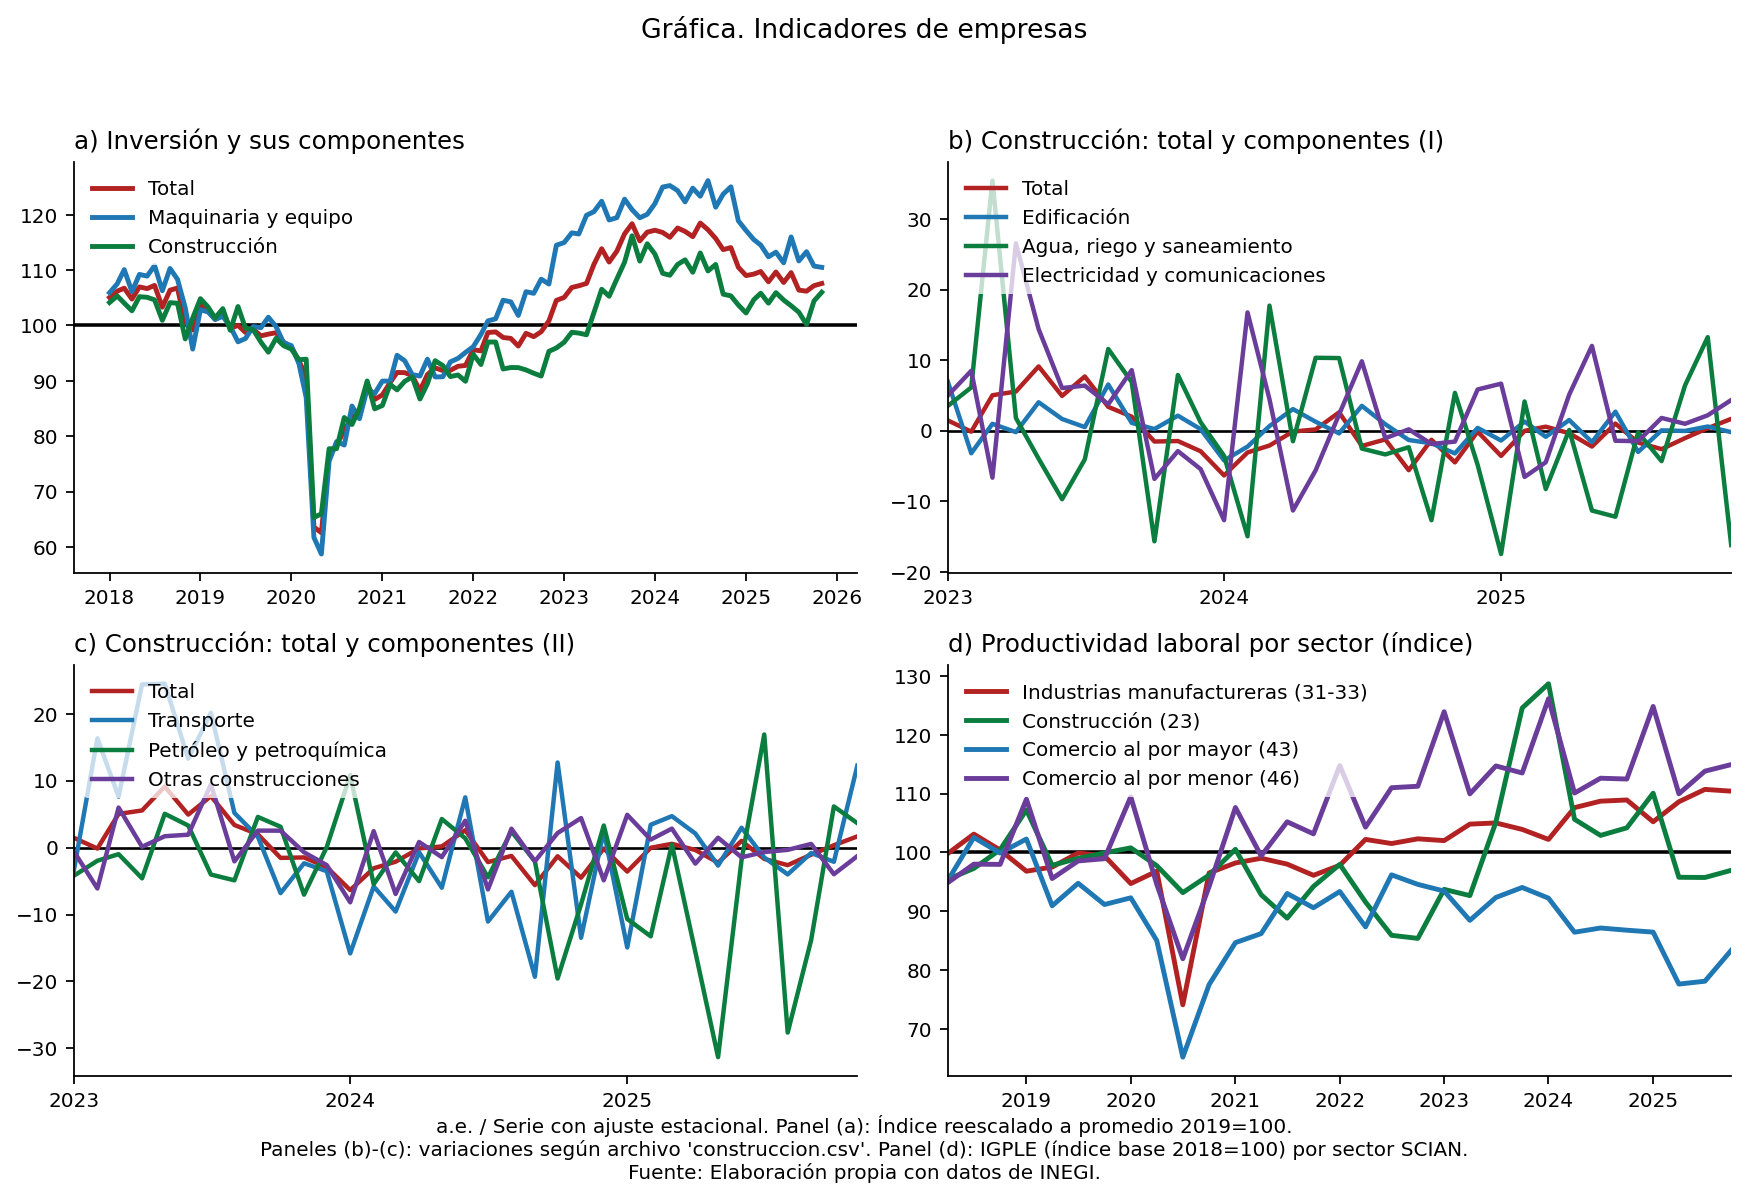

In [31]:
# ============================================================
# FIGURA 2x2 (a)-(d) — CÓDIGO COMPLETO (CORREGIDO + PANEL d CON 4 LÍNEAS)
# (a) IFB (Excel con merges): TOTAL, Maquinaria y equipo, Construcción (rebased 2019=100)
# (b) construccion.csv: Total + 3 componentes (grupo 1)
# (c) construccion.csv: Total + 3 componentes (grupo 2)
# (d) prod_empresas.xlsx (Tabulado, con merges): 4 líneas
#       - 43 Comercio al por mayor
#       - 46 Comercio al por menor
#       - 31-33 Industrias manufactureras
#       - 23 Construcción
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import openpyxl
from openpyxl.utils import range_boundaries

# =========================
# PATHS (montados aquí)
# =========================
PATH_IFB   = "raw/ifb_indice.xlsx"
PATH_CONST = "raw/construccion.csv"
PATH_PROD  = "raw/prod_empresas.xlsx"

START = pd.Timestamp("2018-01-01")
BASE_YEAR = 2019

# =========================
# ESTILO
# =========================
plt.rcParams.update({
    "figure.dpi": 160,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

COL_VINO   = "#b22222"
COL_AZUL   = "#1f77b4"
COL_VERDE  = "#0b7d3e"
COL_MORADO = "#6a3d9a"

def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

def legend_box(ax, loc="upper left"):
    leg = ax.legend(loc=loc, frameon=True)
    leg.get_frame().set_alpha(0.75)
    leg.get_frame().set_linewidth(0.0)
    return leg

def add_base100(ax):
    ax.axhline(100, lw=1.6, color="black", zorder=1)

def add_zero(ax):
    ax.axhline(0, lw=1.2, color="black", zorder=1)

# =========================
# 1) EXCEL: RELLENAR MERGES
# =========================
def sheet_to_matrix_fill_merged(path: str, sheet_name: str) -> pd.DataFrame:
    wb = openpyxl.load_workbook(path, data_only=True)
    ws = wb[sheet_name]

    merged_map = {}
    for r in ws.merged_cells.ranges:
        min_col, min_row, max_col, max_row = range_boundaries(str(r))
        v = ws.cell(min_row, min_col).value
        for rr in range(min_row, max_row + 1):
            for cc in range(min_col, max_col + 1):
                merged_map[(rr, cc)] = v

    data = []
    for rr in range(1, ws.max_row + 1):
        row = []
        for cc in range(1, ws.max_column + 1):
            v = ws.cell(rr, cc).value
            if v is None and (rr, cc) in merged_map:
                v = merged_map[(rr, cc)]
            row.append(v)
        data.append(row)

    return pd.DataFrame(data)

# ============================================
# 2) IFB: MATRIZ INEGI (AÑOS + MESES)
# ============================================
MONTH_MAP = {"ENE":1,"FEB":2,"MAR":3,"ABR":4,"MAY":5,"JUN":6,"JUL":7,"AGO":8,"SEP":9,"OCT":10,"NOV":11,"DIC":12}

def read_inegi_wide_matrix_excel(
    path: str,
    sheet_name: str,
    header_year_row: int = 5,   # 1-based
    header_month_row: int = 6,  # 1-based
    series_start_row: int = 7,  # 1-based
) -> pd.DataFrame:
    mat = sheet_to_matrix_fill_merged(path, sheet_name)
    yr = mat.iloc[header_year_row - 1]
    mo = mat.iloc[header_month_row - 1]

    # localizar "ENE"
    data_start_j = None
    for j, v in enumerate(mo):
        if isinstance(v, str) and v.strip().upper() == "ENE":
            data_start_j = j
            break
    if data_start_j is None:
        raise ValueError("No encontré 'ENE' en fila de meses. Revisa header_month_row.")

    cols_j, dates = [], []
    for j in range(data_start_j, mat.shape[1]):
        y = yr.iloc[j]
        m = mo.iloc[j]
        if y is None or m is None:
            continue
        try:
            y_int = int(str(y).strip())
        except:
            continue
        m_key = str(m).strip().upper()[:3]
        if m_key not in MONTH_MAP:
            continue

        cols_j.append(j)
        dates.append(pd.Timestamp(y_int, MONTH_MAP[m_key], 1))

    records = []
    for i in range(series_start_row - 1, mat.shape[0]):
        c1 = mat.iat[i, 0]
        c2 = mat.iat[i, 1]

        if isinstance(c1, str) and c1.strip().lower().startswith("nota"):
            break
        if c1 is None and c2 is None:
            continue

        name = c1 if c1 is not None else c2
        if not isinstance(name, str):
            continue
        name = re.sub(r"\s+", " ", name.replace("\n", " ")).strip()

        vals = pd.to_numeric(mat.iloc[i, cols_j], errors="coerce").values
        for d, v in zip(dates, vals):
            if pd.notna(v):
                records.append((d, name, float(v)))

    return pd.DataFrame(records, columns=["date","serie","value"]).sort_values(["serie","date"])

def rebase_to_year_avg(s: pd.Series, base_year: int = 2019) -> pd.Series:
    base = s[s.index.year == base_year].mean()
    return (s / base) * 100

def prep_ifb_series(ifb_long: pd.DataFrame, start="2018-01-01", base_year=2019) -> pd.DataFrame:
    df = ifb_long.copy()
    df = df[df["date"] >= pd.Timestamp(start)]
    wide = df.pivot(index="date", columns="serie", values="value").sort_index()
    wide.columns = [re.sub(r"\s+", " ", str(c).replace("\n", " ")).strip() for c in wide.columns]
    wide_rb = wide.apply(lambda col: rebase_to_year_avg(col, base_year=base_year), axis=0)
    return wide_rb

# ============================================
# 3) construccion.csv: filas-año + meses abajo
# ============================================
def read_monthly_csv_with_year_rows(path: str, periodo_col: str = "Periodo") -> pd.DataFrame:
    df_raw = pd.read_csv(path)
    df_raw.columns = [re.sub(r"\s+", " ", str(c).strip()) for c in df_raw.columns]

    month_map = {
        "Enero":1,"Febrero":2,"Marzo":3,"Abril":4,"Mayo":5,"Junio":6,
        "Julio":7,"Agosto":8,"Septiembre":9,"Octubre":10,"Noviembre":11,"Diciembre":12
    }

    records, year = [], None
    for _, row in df_raw.iterrows():
        per = str(row[periodo_col]).strip()

        if re.fullmatch(r"\d{4}", per):
            year = int(per)
            continue
        if year is None:
            continue

        per = re.sub(r"\s+P$", "", per)
        per = re.sub(r"\s+", " ", per)

        m = month_map.get(per, None)
        if m is None:
            continue

        rec = {"date": pd.Timestamp(year, m, 1)}
        for c in df_raw.columns:
            if c == periodo_col:
                continue
            rec[c] = pd.to_numeric(row[c], errors="coerce")
        records.append(rec)

    df = pd.DataFrame(records).sort_values("date").reset_index(drop=True)
    df.columns = [re.sub(r"\s+", " ", str(c).strip()) for c in df.columns]
    return df

def resolve_col(df: pd.DataFrame, target: str) -> str:
    """
    Encuentra la columna cuyo nombre contenga target (case-insensitive).
    """
    t = target.lower().strip()
    for c in df.columns:
        if c == "date":
            continue
        cn = str(c).lower().strip()
        if t and t in cn:
            return c
    if target in df.columns:
        return target
    raise KeyError(f"No pude resolver columna '{target}'. Disponibles: {list(df.columns)}")

# ============================================
# 4) prod_empresas.xlsx: TRIMESTRAL POR SECTOR SCIAN (con merges)
# ============================================
def read_prod_empresas_trimestral(path: str, sheet_name: str = "Tabulado") -> pd.DataFrame:
    """
    Devuelve long: date (timestamp trimestral), sector_scian (str), value (float)
    Detecta columnas: (AÑO, TRIMESTRE) a la derecha de 'Sector SCIAN'.
    """
    mat = sheet_to_matrix_fill_merged(path, sheet_name)

    # localizar fila donde aparece "Sector SCIAN"
    header_row = None
    for i in range(mat.shape[0]):
        row = mat.iloc[i].astype(str)
        if row.str.contains(r"Sector\s+SCIAN", case=False, regex=True).any():
            header_row = i
            break
    if header_row is None:
        raise ValueError("No encontré 'Sector SCIAN' en la hoja.")

    year_row = header_row
    q_row    = header_row + 1

    # localizar columna "Sector SCIAN"
    sector_col = None
    for j in range(mat.shape[1]):
        v = mat.iat[year_row, j]
        if isinstance(v, str) and re.search(r"Sector\s+SCIAN", v, flags=re.I):
            sector_col = j
            break
    if sector_col is None:
        for j in range(mat.shape[1]):
            v = mat.iat[q_row, j]
            if isinstance(v, str) and re.search(r"Sector\s+SCIAN", v, flags=re.I):
                sector_col = j
                break
    if sector_col is None:
        raise ValueError("No pude ubicar la columna 'Sector SCIAN'.")

    yr = mat.iloc[year_row]
    qr = mat.iloc[q_row]

    # construir columnas trimestrales (j -> timestamp)
    time_cols, time_idx = [], []
    for j in range(sector_col + 1, mat.shape[1]):
        y = yr.iloc[j]
        q = qr.iloc[j]
        if y is None or q is None:
            continue

        try:
            y_int = int(str(y).strip())
        except:
            continue

        q_str = str(q).strip().upper()
        m = re.fullmatch(r"([1-4])T", q_str)
        if not m:
            continue

        q_int = int(m.group(1))
        dt = pd.Period(f"{y_int}Q{q_int}", freq="Q").to_timestamp(how="end")

        time_cols.append(j)
        time_idx.append(dt)

    records = []
    for i in range(q_row + 1, mat.shape[0]):
        sector = mat.iat[i, sector_col]
        if sector is None:
            continue
        if isinstance(sector, str) and sector.strip().lower().startswith("notas"):
            break

        sector = re.sub(r"\s+", " ", str(sector).replace("\n", " ")).strip()

        vals = pd.to_numeric(mat.iloc[i, time_cols], errors="coerce").values
        for dt, v in zip(time_idx, vals):
            if pd.notna(v):
                records.append((dt, sector, float(v)))

    return pd.DataFrame(records, columns=["date", "sector_scian", "value"]).sort_values(["sector_scian","date"])

def get_sector_series(prod_long: pd.DataFrame, token: str) -> pd.Series:
    """
    token = string que debe aparecer dentro del texto del sector.
    Devuelve una Series indexada por date.
    """
    m = prod_long["sector_scian"].str.contains(token, case=False, regex=False)
    sub = prod_long[m].copy()
    if sub.empty:
        opts = prod_long["sector_scian"].drop_duplicates().tolist()
        raise KeyError(f"No encontré sector que contenga '{token}'. Sectores disponibles:\n{opts}")
    s = sub.pivot_table(index="date", values="value", aggfunc="mean").sort_index()["value"]
    return s

# =========================
# 5) CARGAR DATOS
# =========================
# (a) IFB
ifb_long = read_inegi_wide_matrix_excel(PATH_IFB, sheet_name="FBKF_indice")
ifb = prep_ifb_series(ifb_long, start=str(START.date()), base_year=BASE_YEAR)

# (b)(c) construcción.csv
constr = read_monthly_csv_with_year_rows(PATH_CONST, periodo_col="Periodo")
constr = constr[constr["date"] >= START].copy()

# (d) prod_empresas.xlsx (trimestral)
prod_long = read_prod_empresas_trimestral(PATH_PROD, sheet_name="Tabulado")
prod_long = prod_long[prod_long["date"] >= START].copy()

# Series (d)
s_may = get_sector_series(prod_long, "43 Comercio al por mayor")
s_men = get_sector_series(prod_long, "46 Comercio al por menor")
s_man = get_sector_series(prod_long, "31-33")          # Industrias manufactureras
s_con = get_sector_series(prod_long, "23 Construcción")

# =========================
# 6) GRUPOS (b) y (c)
# =========================
g1_targets = ["Total", "Edificación", "Agua, riego", "Electricidad"]
g2_targets = ["Total", "Transporte", "Petróleo", "Otras construcciones"]

g1_cols = [resolve_col(constr, t) for t in g1_targets]
g2_cols = [resolve_col(constr, t) for t in g2_targets]

# =========================
# 7) FIGURA 2x2
# =========================
fig, axes = plt.subplots(2, 2, figsize=(11.6, 7.6))
(ax_a, ax_b), (ax_c, ax_d) = axes

# -------- (a) IFB --------
a_df = ifb[["TOTAL", "Maquinaria y equipo", "Construcción"]].copy()
ax_a.plot(a_df.index, a_df["TOTAL"],               lw=2.2, color=COL_VINO,  label="Total")
ax_a.plot(a_df.index, a_df["Maquinaria y equipo"], lw=2.2, color=COL_AZUL,  label="Maquinaria y equipo")
ax_a.plot(a_df.index, a_df["Construcción"],        lw=2.2, color=COL_VERDE, label="Construcción")
add_base100(ax_a)
style_axis(ax_a)
ax_a.set_title("a) Inversión y sus componentes", loc="left", pad=6)
legend_box(ax_a, loc="upper left")

# -------- (b) Construcción (I) --------
colors_b = [COL_VINO, COL_AZUL, COL_VERDE, COL_MORADO]
labels_b = ["Total", "Edificación", "Agua, riego y saneamiento", "Electricidad y comunicaciones"]
for c, col, lab in zip(colors_b, g1_cols, labels_b):
    ax_b.plot(constr["date"], constr[col], lw=2.0, color=c, label=lab)
add_zero(ax_b)
style_axis(ax_b)
ax_b.set_title("b) Construcción: total y componentes (I)", loc="left", pad=6)
legend_box(ax_b, loc="upper left")
ax_b.set_xlim(pd.Timestamp("2023-01-01"), constr["date"].max())

# -------- (c) Construcción (II) --------
colors_c = [COL_VINO, COL_AZUL, COL_VERDE, COL_MORADO]
labels_c = ["Total", "Transporte", "Petróleo y petroquímica", "Otras construcciones"]
for c, col, lab in zip(colors_c, g2_cols, labels_c):
    ax_c.plot(constr["date"], constr[col], lw=2.0, color=c, label=lab)
add_zero(ax_c)
style_axis(ax_c)
ax_c.set_title("c) Construcción: total y componentes (II)", loc="left", pad=6)
legend_box(ax_c, loc="upper left")
ax_c.set_xlim(pd.Timestamp("2023-01-01"), constr["date"].max())

# -------- (d) Productividad (IGPLE) por sector (4 líneas) --------
ax_d.plot(s_man.index, s_man.values, lw=2.2, color=COL_VINO,   label="Industrias manufactureras (31-33)")
ax_d.plot(s_con.index, s_con.values, lw=2.2, color=COL_VERDE,  label="Construcción (23)")
ax_d.plot(s_may.index, s_may.values, lw=2.2, color=COL_AZUL,   label="Comercio al por mayor (43)")
ax_d.plot(s_men.index, s_men.values, lw=2.2, color=COL_MORADO, label="Comercio al por menor (46)")

add_base100(ax_d)  # si prefieres no marcar 100, bórralo
style_axis(ax_d)
ax_d.set_title("d) Productividad laboral por sector (índice)", loc="left", pad=6)
legend_box(ax_d, loc="upper left")

xmin = min(s_man.index.min(), s_con.index.min(), s_may.index.min(), s_men.index.min())
xmax = max(s_man.index.max(), s_con.index.max(), s_may.index.max(), s_men.index.max())
ax_d.set_xlim(xmin, xmax)

# -------- Título + nota al pie --------
fig.suptitle("Gráfica. Indicadores de empresas", y=0.98, fontsize=12)

fig.text(
    0.5, 0.02,
    "a.e. / Serie con ajuste estacional. Panel (a): Índice reescalado a promedio 2019=100.\n"
    "Paneles (b)-(c): variaciones según archivo 'construccion.csv'. Panel (d): IGPLE (índice base 2018=100) por sector SCIAN.\n"
    "Fuente: Elaboración propia con datos de INEGI.",
    ha="center", va="bottom", fontsize=9
)

plt.tight_layout(rect=[0.03, 0.06, 0.98, 0.95])
plt.show()
